# Kaggriculture Tutorial

Farm your way to market dominance! Players harvest produce and animal products to sell in a dynamic market.

## Game Mechanics 
 
- **Farmer**: takes one action per turn over a season with 30 days and 24 turns per day (720 total).
- **Crops and animals**: each have their own seed cost, time to first yield, and total payout. 
- **Daily care**: plants need watering every day or they turn to weeds, animals need feeding or they escape.
- **Market prices**: move with supply, selling a product pushes its price down, and crops vary in how hard they crash from a glut.
- **Town shops** unlock over the season and steadily buy products, lifting prices over time.
- **Farm hands** can be hired for the day, with increasing costs for each hire per day. 
- **Farm expansion**: start with one quadrant of land and can buy the other three for an escalating fee.
- **Shed**: holds harvested goods but caps at 100 items, anything past that is discarded at end of day.
 - **Win condition**: whoever has the most money in the bank at the end of the season wins.

In [1]:
from kaggle_environments import make

env = make("kaggriculture", debug=True)
print(f"Environment: {env.name} v{env.version}")
print(f"Players: {env.specification.agents}")
print(f"Max steps: {env.configuration.episodeSteps}")

Environment: kaggriculture v0.1.0
Players: [2]
Max steps: 720


## Understanding the Observation

Each turn your agent receives an observation with:

- **`player`** — your player id (`0` or `1`).
- **`day`** / **`hour`** — the current in-game day (0-indexed) and turn within that day (0-indexed; there are `turnsPerDay` turns per day).
- **`farms`** — a list of both players' public farm state, indexed by player id. Each farm has:
    - `money` — current bank balance
    - `tiles` — a `boardSize × boardSize` grid indexed `tiles[y][x]`; each cell is `None` (empty), `"LOCKED"` (unowned quadrant), or a dict describing a `PLANT`, `WEED`, `COOP`, or `PASTURE` (see below)
    - `farmer` — `[x, y]` position of your main farmer
    - `hands` — `[x, y]` positions of any hired hands active today
    - `unlocked_quadrants` — subset of `["NW", "NE", "SW", "SE"]`
    - `hires_today` — number of hires already made today (drives the next `HIRE` price)
- **`market`** (shared) — `inventory` and current `prices` per product (`WHEAT, CARROT, TOMATO, STRAWBERRY, MELON, EGG, MILK, WOOL, FERTILIZER`).
- **`town`** (shared) — `unlocked_shops`, the list of shops currently generating per-tick demand.
- **`private`** — your own hidden state (not visible to your opponent):
  - `shed` — counts of every product and animal (`GOOSE`, `COW`, `SHEEP`) stored in your shed
  - `seeds` — seed counts per crop
  - `inventories` — per-unit carried inventories; `[0]` is your main farmer, `[1..]` are today's hired hands in order

Tile dicts come in a few shapes:

- **Plant**: `{kind: "PLANT", crop, planted_day, watered_today, consecutive_unwatered, yield_units, max_lifespan_step, fertilized_until_day}` — `consecutive_unwatered >= 2` turns the tile to a weed at end of day.
- **Weed**: `{kind: "WEED"}` — must be `DIG`-ed before the tile is usable again.
- **Coop / Pasture** (empty): `{kind: "COOP" | "PASTURE"}`.
- **Coop / Pasture** (occupied): adds `animal, placed_day, yield_units, fed_today, consecutive_unfed, cared_today, fertilizer_available, pending_care_bonus`. `consecutive_unfed >= 2` means the animal escapes.

Your agent returns a dict of actions for the farmer, any farm hands, and the market: `{"farmer": 'PASS', "hands": [], "market": []}`


In [2]:
# Run a quick game to see what the observation looks like
env = make("kaggriculture", debug=True)
env.run(["random", "random"])

# Peek at the initial observation
obs = env.steps[1][0].observation  # step 1 = first action step
items = obs.market.prices.keys()
print(f"Player: {obs.player}")
print(f"Player {obs.player}'s Unlocked Farm Areas: {obs.farms[obs.player].unlocked_quadrants}")
for i in items:
    print(f"{i} Price: {obs.market.prices[i]}")

Player: 0
Player 0's Unlocked Farm Areas: ['NW']
WHEAT Price: 26
CARROT Price: 36
TOMATO Price: 60
STRAWBERRY Price: 128
MELON Price: 256
EGG Price: 50
MILK Price: 169
WOOL Price: 206
FERTILIZER Price: 100


In [61]:
def print_observation(obs):
    # Top-level information
    print("=== GENERAL ===")
    print(f"Remaining overage time: {obs.remainingOverageTime}")
    print(f"Step: {obs.step}")
    print(f"Player: {obs.player}")
    print(f"Day: {obs.day}")
    print(f"Hour: {obs.hour}")

    # Farms
    print("\n=== FARMS ===")

    for i, farm in enumerate(obs.farms):
        print(f"\n--- Farm {i} ---")
        print(f"Money: {farm.money}")
        print(f"Farmer position: {farm.farmer}")
        print(f"Hands: {farm.hands}")
        print(f"Unlocked quadrants: {farm.unlocked_quadrants}")
        print(f"Hires today: {farm.hires_today}")

        # Tiles
        print("Tiles:")

        for row in farm.tiles:
            tile_row = ""

            for tile in row:
                if tile is None:
                    tile_row += ". "
                elif tile == "LOCKED":
                    tile_row += "X "
                else:
                    tile_row += f"{tile} "

            print(tile_row)

    # Private information
    print("\n=== PRIVATE ===")

    print("\nShed:")
    for item, qty in obs.private.shed.items():
        print(f"  {item}: {qty}")

    print("\nSeeds:")
    for seed, qty in obs.private.seeds.items():
        print(f"  {seed}: {qty}")

    print("\nInventories:")
    for i, inv in enumerate(obs.private.inventories):
        print(f"  Inventory {i}: {inv}")

    # Market
    print("\n=== MARKET ===")

    print("\nInventory:")
    for item, qty in obs.market.inventory.items():
        print(f"  {item}: {qty}")

    print("\nPrices:")
    for item, price in obs.market.prices.items():
        print(f"  {item}: {price}")

    # Town
    print("\n=== TOWN ===")
    print(f"Unlocked shops: {obs.town.unlocked_shops}")

In [68]:
agent_0 = "submission/submission_example.py"
agent_1 = "submission/test/main.py"
env.run([agent_0, agent_1])
obs = env.steps[31][0].observation
# obs = env.steps[70][1].observation
print_observation(obs)

=== GENERAL ===
Remaining overage time: 60
Step: 31
Player: 0
Day: 1
Hour: 7

=== FARMS ===

--- Farm 0 ---
Money: 1876.0
Farmer position: [2, 3]
Hands: [[4, 4], [5, 4]]
Unlocked quadrants: ['NW', 'NE']
Hires today: 2
Tiles:
. . . . . . . . . . 
. . . . . . . . . . 
. . . . . . . . . . 
. . {'kind': 'PLANT', 'crop': 'CARROT', 'planted_day': 0, 'watered_today': False, 'consecutive_unwatered': 0, 'yield_units': 1, 'max_lifespan_step': 96, 'fertilized_until_day': -1} {'kind': 'PLANT', 'crop': 'CARROT', 'planted_day': 0, 'watered_today': False, 'consecutive_unwatered': 0, 'yield_units': 1, 'max_lifespan_step': 96, 'fertilized_until_day': -1} {'kind': 'PLANT', 'crop': 'CARROT', 'planted_day': 0, 'watered_today': False, 'consecutive_unwatered': 0, 'yield_units': 1, 'max_lifespan_step': 96, 'fertilized_until_day': -1} . . . . . 
. . {'kind': 'PLANT', 'crop': 'CARROT', 'planted_day': 0, 'watered_today': True, 'consecutive_unwatered': 0, 'yield_units': 1, 'max_lifespan_step': 96, 'fertilized_un

## Agent 1: Melon Maxxer

Our first agent is straightforward:
1. Whenever it runs out of melon seeds and has the cash, buy one more.
2. Walk to the nearest open tile and plant a melon; if it's already standing on a melon plant, water it (or harvest it once it's fully grown).
3. Once melons pile up in the shed, only sell them if the market price is above a threshold, otherwise hold and wait for a better price.
4. Roll the proceeds back into more seeds and repeat.

This demonstrates the core aspects of the game: reading observations, maintaining the farm, and watching the market.   

In [8]:
from kaggle_environments.envs.kaggriculture.kaggriculture import CROPS

MELON_SEED_COST = CROPS["MELON"]["seed"]
MELON_MAX_YIELD_DAY = CROPS["MELON"]["max_yield_day"]
SELL_THRESHOLD = 200

def _step_toward(fx, fy, tx, ty):
    if fx > tx:
        return "WEST"
    if fx < tx:
        return "EAST"
    if fy > ty:
        return "NORTH"
    if fy < ty:
        return "SOUTH"
    return None

def _find_target_tile(farm, board_size, have_seed):
    fx, fy = farm["farmer"]
    candidates = []
    for y in range(board_size):
        for x in range(board_size):
            tile = farm["tiles"][y][x]
            if isinstance(tile, dict) and tile.get("kind") == "PLANT" and tile["crop"] == "MELON":
                purpose = None
                # Harvest if ripe.
                age_ok = tile["yield_units"] > 0
                if age_ok and tile.get("planted_day") is not None:
                    purpose = "harvest"
                if not tile["watered_today"]:
                    purpose = "water" if purpose is None else purpose
                if purpose:
                    candidates.append((x, y, purpose))
            elif tile is None and have_seed:
                candidates.append((x, y, "plant"))

    if not candidates:
        return None

    priority = {"harvest": 0, "water": 1, "plant": 2}
    candidates.sort(key=lambda c: (priority[c[2]], abs(c[0] - fx) + abs(c[1] - fy)))
    return candidates[0]

def melon_maxxer(obs):
    farms = obs.get("farms", [])
    player = obs.get("player", 0)
    private = obs.get("private", {}) or {}
    if not farms or player >= len(farms):
        return {"farmer": ["PASS"], "hands": [], "market": []}

    farm = farms[player]
    board_size = len(farm["tiles"])
    fx, fy = farm["farmer"]
    tile = farm["tiles"][fy][fx]
    day = obs.get("day", 0)

    seeds = private.get("seeds", {})
    shed = private.get("shed", {})
    market_prices = (obs.get("market", {}) or {}).get("prices", {})
    melon_price = market_prices.get("MELON", 0)

    market = []

    # Sell melons only when the market is paying enough.
    melons_in_shed = shed.get("MELON", 0)
    if melons_in_shed > 0 and melon_price >= SELL_THRESHOLD:
        market.append(["SELL", "MELON", melons_in_shed])

    # Top up seed inventory so the next empty tile can be planted.
    if seeds.get("MELON", 0) == 0 and farm["money"] >= MELON_SEED_COST:
        market.append(["BUY_SEED", "MELON", 1])

    # Decide farmer action.
    farmer = ["PASS"]

    if isinstance(tile, dict) and tile.get("kind") == "PLANT" and tile["crop"] == "MELON":
        age = day - tile["planted_day"]
        if age >= MELON_MAX_YIELD_DAY and tile["yield_units"] > 0:
            farmer = ["HARVEST"]
        elif not tile["watered_today"]:
            farmer = ["WATER"]
        else:
            target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
            if target:
                step = _step_toward(fx, fy, target[0], target[1])
                if step:
                    farmer = [step]
    elif tile is None and seeds.get("MELON", 0) > 0:
        farmer = ["PLANT", "MELON"]
    else:
        target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
        if target:
            step = _step_toward(fx, fy, target[0], target[1])
            if step:
                farmer = [step]

    return {"farmer": farmer, "hands": [], "market": market}

In [ ]:
# Test it against the random agent
env = make("kaggriculture", debug=True)
env.run([melon_maxxer, "random"])

final = env.steps[-1]
for i, s in enumerate(final):
    print(f"Player {i}: reward={s.reward}, status={s.status}")

env.render(mode="ipython", width=800, height=600)

## What's wrong with this agent?

The melon agent has a few problems:
  - It never hires farm hands or buys more land, so it's stuck with one farmer working a single quadrant.     
  - It only grows melons, so when other crops are fetching a higher price it has nothing to sell.
  - It never fertilizes its plants, leaving a yield bonus on the table.                           
  - When it does sell, it dumps the entire inventory in one order, which can crash the melon price below the       
  threshold partway through the sale.                                                                         
                                      
Now it's your turn to make improvements!

## Making a submission

You can either submit a main.py, a tar.gz (or zip) with a main.py in it, or submit a notebook with a main.py or submission.tar.gz

There are three ways to subit.
1. using the [Submit Agent](https://www.kaggle.com/competitions/kaggriculture-gdm-internal) button on the homepage and uploading the file
2. using the Kaggle CLI (as described in agents.py in the competition dataset)
3. submitting a notebook with a submission.py or submission.tar.gz

In [38]:
%%writefile submission/submission.py
from kaggle_environments.envs.kaggriculture.kaggriculture import CROPS

MELON_SEED_COST = CROPS["MELON"]["seed"]
MELON_MAX_YIELD_DAY = CROPS["MELON"]["max_yield_day"]
SELL_THRESHOLD = 200

def _step_toward(fx, fy, tx, ty):
    if fx > tx:
        return "WEST"
    if fx < tx:
        return "EAST"
    if fy > ty:
        return "NORTH"
    if fy < ty:
        return "SOUTH"
    return None

def _find_target_tile(farm, board_size, have_seed):
    fx, fy = farm["farmer"]
    candidates = []
    for y in range(board_size):
        for x in range(board_size):
            tile = farm["tiles"][y][x]
            if isinstance(tile, dict) and tile.get("kind") == "PLANT" and tile["crop"] == "MELON":
                purpose = None
                # Harvest if ripe.
                age_ok = tile["yield_units"] > 0
                if age_ok and tile.get("planted_day") is not None:
                    purpose = "harvest"
                if not tile["watered_today"]:
                    purpose = "water" if purpose is None else purpose
                if purpose:
                    candidates.append((x, y, purpose))
            elif tile is None and have_seed:
                candidates.append((x, y, "plant"))

    if not candidates:
        return None

    priority = {"harvest": 0, "water": 1, "plant": 2}
    candidates.sort(key=lambda c: (priority[c[2]], abs(c[0] - fx) + abs(c[1] - fy)))
    return candidates[0]

def melon_maxxer(obs):
    farms = obs.get("farms", [])
    player = obs.get("player", 0)
    private = obs.get("private", {}) or {}
    if not farms or player >= len(farms):
        return {"farmer": ["PASS"], "hands": [], "market": []}

    farm = farms[player]
    board_size = len(farm["tiles"])
    fx, fy = farm["farmer"]
    tile = farm["tiles"][fy][fx]
    day = obs.get("day", 0)

    seeds = private.get("seeds", {})
    shed = private.get("shed", {})
    market_prices = (obs.get("market", {}) or {}).get("prices", {})
    melon_price = market_prices.get("MELON", 0)

    market = []

    # Sell melons only when the market is paying enough.
    melons_in_shed = shed.get("MELON", 0)
    if melons_in_shed > 0 and melon_price >= SELL_THRESHOLD:
        market.append(["SELL", "MELON", melons_in_shed])

    # Top up seed inventory so the next empty tile can be planted.
    if seeds.get("MELON", 0) == 0 and farm["money"] >= MELON_SEED_COST:
        market.append(["BUY_SEED", "MELON", 1])

    # Decide farmer action.
    farmer = ["PASS"]

    if isinstance(tile, dict) and tile.get("kind") == "PLANT" and tile["crop"] == "MELON":
        age = day - tile["planted_day"]
        if age >= MELON_MAX_YIELD_DAY and tile["yield_units"] > 0:
            farmer = ["HARVEST"]
        elif not tile["watered_today"]:
            farmer = ["WATER"]
        else:
            target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
            if target:
                step = _step_toward(fx, fy, target[0], target[1])
                if step:
                    farmer = [step]
    elif tile is None and seeds.get("MELON", 0) > 0:
        farmer = ["PLANT", "MELON"]
    else:
        target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
        if target:
            step = _step_toward(fx, fy, target[0], target[1])
            if step:
                farmer = [step]

    return {"farmer": farmer, "hands": [], "market": market}

Writing submission/submission.py


## Submit to competition

Now that we have a main.py, all you need to do is click "Submit to competition" on the right and watch your entry show up on the competition leaderboard! Best of luck!

# Visualize Tools
> From Someone else code

In [ ]:
# Works on Kaggle with Internet on (first run upgrades kaggle-environments if the image is stale).
import contextlib, glob, io, os, subprocess, sys
from importlib import metadata

def _version_ok():
    try:  # checked without importing, so an upgrade below actually takes effect
        return tuple(int(x) for x in
                     metadata.version("kaggle-environments").split(".")[:3]) >= (1, 32, 3)
    except Exception:
        return False

if not _version_ok():
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--progress-bar", "off",
                        "-U", "kaggle-environments>=1.32.3"], check=True, capture_output=True)
    except Exception as e:
        raise RuntimeError("This guide needs kaggle-environments >= 1.32.3 — "
                           "turn Internet ON in the notebook settings and rerun.") from e

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import logging
logging.disable(logging.INFO)  # other bundled envs log noise on import; mute it
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    import kaggle_environments
    from kaggle_environments import make
logging.disable(logging.NOTSET)
from kaggle_environments.envs.kaggriculture.kaggriculture import (
    CROPS, ANIMALS, MARKET_PARAMS, MARKET_I0, SHOPS, LAND_ORDER, LAND_PRICES,
    PRODUCTS, TOWN_CENTER_DEMAND_SCHEDULE, market_price,
)

plt.rcParams.update({
    "figure.dpi": 90, "savefig.dpi": 90, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
})

# Colorblind-safe palette (validated: CVD ΔE and lightness checks pass)
CROP_C = {"WHEAT": "#C99700", "CARROT": "#B84A00", "TOMATO": "#9E2B72",
          "STRAWBERRY": "#DB6FA9", "MELON": "#00795F"}
PROD_C = {**CROP_C, "EGG": "#56A8D8", "MILK": "#0059A1", "WOOL": "#A8641A",
          "FERTILIZER": "#6B4F9E"}
P0, P1 = "#0072B2", "#D55E00"          # our bot / opponent
# Surface tones lifted from the visualizer that ships with the environment, so the
# farms here look like the farms in the official replay player.
SOIL, TILLED, WILD = "#efe7ce", "#e8d2a6", "#c2caa4"
WOOD, WOOD_DARK, INK = "#8b6f44", "#3a2412", "#3c3b37"
BASE = {p: MARKET_PARAMS[p]["base"] for p in PRODUCTS}

def one_shot_units(crop):
    # Watering during the bonus window adds +1/day (+2 if fertilized), capped at max_yield.
    c = CROPS[crop]
    window = range((c["max_yield_day"] + 1) // 2, c["max_yield_day"] + 1)
    return min(c["max_yield"], 1 + len(list(window)))

def one_shot_days(crop):
    # The tile is free once the plant is BOTH harvestable and done growing. Watering adds +1/day
    # from a base of 1, starting at the window, so the cap can bind before max_yield_day: a melon
    # is finished on day 10, not 12. Wheat and carrot never reach their cap, so nothing changes.
    c = CROPS[crop]
    cap_day = (c["max_yield_day"] + 1) // 2 + c["max_yield"] - 2
    return max(c["first_yield_day"], min(cap_day, c["max_yield_day"]))

def ongoing_days(crop):
    # The days a fruit can be picked up. _daily_refresh_plants runs with next_day = day + 1, so the
    # unit that forms overnight is in your hands on the morning of first_yield_day, then every
    # `interval` days after that, max_yield times.
    c = CROPS[crop]
    return [c["first_yield_day"] + k * c["interval"] for k in range(c["max_yield"])]

def crop_econ():
    # Profit per tile-day at base prices, daily watering, no fertilizer.
    rows = []
    for crop, c in CROPS.items():
        if c["ongoing"]:
            days = ongoing_days(crop)
            units, occupied = c["max_yield"], days[-1]       # DIG frees the tile the same day
        else:
            units, occupied = one_shot_units(crop), one_shot_days(crop)
        revenue = units * BASE[crop]
        profit = revenue - c["seed"]
        rows.append({"crop": crop, "seed $": c["seed"], "tile-days": occupied, "units": units,
                     "base price": BASE[crop], "revenue $": revenue, "profit $": profit,
                     "profit / tile-day": round(profit / occupied, 1)})
    return pd.DataFrame(rows).sort_values("profit / tile-day", ascending=False).reset_index(drop=True)

def draw_farm(ax, farm, title=""):
    # One farm, drawn in the environment's own colours; tiles[y][x] with row 0 on top.
    from matplotlib.patches import FancyBboxPatch

    def tile(x, y, fc, ec="white", lw=1.0, alpha=1.0):
        ax.add_patch(FancyBboxPatch((x + .07, n - 1 - y + .07), .86, .86,
                                    boxstyle="round,pad=0,rounding_size=0.16",
                                    fc=fc, ec=ec, lw=lw, alpha=alpha))

    n = len(farm["tiles"])
    ax.add_patch(plt.Rectangle((-.15, -.15), n + .3, n + .3, fc=SOIL, ec="none", zorder=0))
    for y in range(n):
        for x in range(n):
            t = farm["tiles"][y][x]
            if t == "LOCKED":                       # wild land, not bought yet
                tile(x, y, WILD, ec="#b3bd94", lw=.8)
                continue
            tile(x, y, TILLED, ec=SOIL, lw=.8)      # ground you own and work
            if not isinstance(t, dict):
                continue
            k = t.get("kind")
            if k == "PLANT":
                ripe = t.get("yield_units", 0) > 0
                tile(x, y, CROP_C[t["crop"]], alpha=1.0 if ripe else .45)
                if ripe:                            # a dot means there is something to harvest
                    ax.plot(x + .5, n - 1 - y + .5, "o", ms=3.4, mfc="white", mec="none", zorder=6)
            elif k == "WEED":
                tile(x, y, "#6E7351", alpha=.55)
            elif "animal" in t:
                tile(x, y, PROD_C[ANIMALS[t["animal"]]["product"]])
            elif k in ("COOP", "PASTURE"):
                tile(x, y, WOOD, alpha=.5)
    ax.plot([n/2, n/2], [0, n], color=WOOD_DARK, lw=2.4, alpha=.85, zorder=4)
    ax.plot([0, n], [n/2, n/2], color=WOOD_DARK, lw=2.4, alpha=.85, zorder=4)
    ax.add_patch(FancyBboxPatch((n/2 - .62, n/2 - .62), 1.24, 1.24,
                                boxstyle="round,pad=0,rounding_size=0.18",
                                fc=WOOD_DARK, ec=SOIL, lw=1.6, zorder=5))
    ax.text(n/2, n/2, "shed", ha="center", va="center", fontsize=6.5, color=SOIL, zorder=6)
    fx, fy = farm["farmer"]
    ax.plot(fx + .5, n - 1 - fy + .5, "o", ms=8.5, mfc=P0, mec="white", mew=1.4, zorder=7)
    for hx, hy in farm.get("hands", []):
        ax.plot(hx + .5, n - 1 - hy + .5, "o", ms=5.5, mfc=P0, mec="white", mew=1.1, zorder=7)
    ax.set_xlim(-.2, n + .2); ax.set_ylim(-.2, n + .2)
    ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=11, color=INK)

def season_gif_both(steps, out="gif/season_both.gif", fps=5):
    from matplotlib.animation import FuncAnimation, PillowWriter
    os.makedirs(os.path.dirname(out), exist_ok=True)
    days, last = day_frames(steps)
    money = [[s[0]["observation"]["farms"][p]["money"] for s in steps] for p in (0, 1)]
    top = max(max(money[0]), max(money[1])) * 1.08

    fig = plt.figure(figsize=(11.5, 3.6))
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[1, 1, 1.25],
        wspace=0.4
    )
    axF0 = fig.add_subplot(gs[0])
    axF1 = fig.add_subplot(gs[1])
    axM = fig.add_subplot(gs[2])

    def frame(i):
        k = last[i]
        axF0.clear(); axF1.clear(); axM.clear()
        farm0 = steps[k][0]["observation"]["farms"][0]
        farm1 = steps[k][0]["observation"]["farms"][1]
        draw_farm(axF0, farm0, title=f"Player 0 — Day {days[i]}")
        draw_farm(axF1, farm1, title=f"Player 1 — Day {days[i]}")
        axM.plot(money[0][:k + 1], color=P0, lw=2.4, label=f"Player 0")
        axM.plot(money[1][:k + 1], color=P1, lw=2.4, label=f"Player 1")
        axM.set_xlim(0, len(steps)); axM.set_ylim(0, top)
        axM.set_title("Coins in the bank", fontsize=11.5, color=INK, weight="bold")
        axM.set_xlabel("turn", fontsize=9)
        axM.legend(fontsize=8.5, frameon=False, loc="upper left")

    FuncAnimation(fig, frame, frames=len(last)).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return out

def day_frames(steps):
    # Index of the last turn of every in-game day, so one frame is one day.
    days = sorted({s[0]["observation"]["day"] for s in steps})
    return days, [max(i for i, s in enumerate(steps) if s[0]["observation"]["day"] == d)
                  for d in days]


def season_gif(steps, out="season.gif", fps=5):
    # One frame per in-game day: the farm on the left, the money race on the right.
    from matplotlib.animation import FuncAnimation, PillowWriter
    days, last = day_frames(steps)
    money = [[s[0]["observation"]["farms"][p]["money"] for s in steps] for p in (0, 1)]
    top = max(max(money[0]), max(money[1])) * 1.08

    fig, (axF, axM) = plt.subplots(1, 2, figsize=(7.8, 3.6),
                                   gridspec_kw={"width_ratios": [1.05, 1.05]})
    def frame(i):
        k = last[i]
        axF.clear(); axM.clear()
        draw_farm(axF, steps[k][0]["observation"]["farms"][0])
        axF.set_title(f"Day {days[i]} of {days[-1]}", fontsize=11.5, color=INK, weight="bold")
        axM.plot(money[0][:k + 1], color=P0, lw=2.4, label="Carrot Crew")
        axM.plot(money[1][:k + 1], color=P1, lw=2.4, label="built-in starter")
        axM.set_xlim(0, len(steps)); axM.set_ylim(0, top)
        axM.set_title("Coins in the bank", fontsize=11.5, color=INK, weight="bold")
        axM.set_xlabel("turn", fontsize=9)
        axM.legend(fontsize=8.5, frameon=False, loc="upper left")

    FuncAnimation(fig, frame, frames=len(last)).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return out


import glob, os

def data_file(name):
    # The attached dataset on Kaggle, a differently-named copy of it, or a local checkout.
    for d in ["/kaggle/input/kaggriculture-episodes", *glob.glob("/kaggle/input/*"),
              "episodes", "../episodes"]:
        if os.path.exists(f"{d}/{name}"):
            return f"{d}/{name}"
    raise FileNotFoundError(
        f"{name} not found. Attach the dataset: Add Input -> Datasets -> search "
        "'kaggriculture-episodes' (georgymamarin/kaggriculture-episodes)."
    )

def load_table(stem):
    for ext, reader in ((".parquet", pd.read_parquet), (".csv", pd.read_csv)):
        try:
            return reader(data_file(f"{stem}{ext}"))
        except FileNotFoundError:
            continue
    raise FileNotFoundError(f"no {stem}.csv or {stem}.parquet in the attached dataset")


def hero_gif(out="hero.gif", fps=5):
    # A real ladder season: the farm fills up while the town's appetite lifts prices.
    import json
    from matplotlib.animation import FuncAnimation, PillowWriter

    ladder = load_table("episodes")
    ladder = ladder[ladder["type"] == "EPISODE_TYPE_PUBLIC"].copy()
    ladder["top"] = ladder[["bank_0", "bank_1"]].max(axis=1)
    row = ladder.sort_values("top", ascending=False).iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    steps = json.loads(pd.read_parquet(
        data_file("replays.parquet"),
        filters=[("episode_id", "==", int(row.episode_id))]).iloc[0].replay_json)["steps"]

    days, last = day_frames(steps)
    watch = ["MILK", "STRAWBERRY", "MELON", "WHEAT"]
    series = {p: [steps[k][0]["observation"]["market"]["prices"][p] for k in last] for p in watch}
    ceiling = max(max(v) for v in series.values()) * 1.12

    fig = plt.figure(figsize=(8.0, 3.7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.22], left=.02, right=.9, top=.8, bottom=.14,
                          wspace=.12)
    axF, axP = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    def frame(i):
        axF.clear(); axP.clear()
        farm = steps[last[i]][0]["observation"]["farms"][seat]
        draw_farm(axF, farm)
        axF.set_title(f"Day {days[i]}   ${farm['money']:,.0f}", fontsize=12, color=INK, weight="bold")
        for mark, mult in ((10, "x2"), (20, "x4")):
            if days[i] >= mark:                       # the town's appetite steps up here
                axP.axvline(mark, color="#b9ae95", lw=1.2, ls=":")
                axP.text(mark + .3, ceiling * .04, f"town {mult}", fontsize=8, color="#8A7F6B")
        spread = sorted(watch, key=lambda p: -series[p][i])
        placed = None
        for prod in spread:
            axP.plot(days[:i + 1], series[prod][:i + 1], lw=2.6, color=PROD_C[prod])
            y = series[prod][i]
            if placed is not None and y > placed - ceiling * .07:
                y = placed - ceiling * .07                          # stack labels, never overlap
            placed = y
            axP.text(days[i] + .6, y, f"{prod.title()} ${series[prod][i]}",
                     fontsize=8.5, color=PROD_C[prod], va="center", weight="bold")
        axP.set_xlim(0, days[-1] * 1.34); axP.set_ylim(0, ceiling)
        axP.set_title("What the town pays", fontsize=12, color=INK, weight="bold")
        axP.set_xlabel("day", fontsize=9)
        axP.tick_params(labelsize=8.5)

    FuncAnimation(fig, frame, frames=len(days)).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)

    stock = [steps[k][0]["observation"]["market"]["inventory"]["MELON"] for k in last]
    jump = max(range(1, len(stock)), key=lambda i: stock[i] - stock[i - 1])
    print(f"Biggest melon dump in this game: {stock[jump] - stock[jump - 1]} sold into the market "
          f"on day {days[jump]}, price ${series['MELON'][jump - 1]} -> ${series['MELON'][jump]}.")
    return out


def dump_gif(item="MELON", n=200, out="dump.gif", fps=10):
    # Sell one unit at a time into an untouched market and watch the price walk down.
    from matplotlib.animation import FuncAnimation, PillowWriter
    prices = [market_price(item, MARKET_I0 + k) for k in range(n)]
    earned = np.cumsum(prices)
    dream = np.arange(1, n + 1) * prices[0]          # if the price never moved
    shed = 100                                       # shedCapacity: one dump can be this big
    step = 5

    fig, (axP, axR) = plt.subplots(1, 2, figsize=(8.0, 3.4))
    def frame(f):
        k = min((f + 1) * step, n) - 1
        axP.clear(); axR.clear()
        axP.plot(range(n), prices, lw=2.6, color=CROP_C[item], alpha=.3)
        axP.plot(range(k + 1), prices[:k + 1], lw=3, color=CROP_C[item])
        axP.plot(k, prices[k], "o", ms=9, color=CROP_C[item], mec="white", mew=1.6)
        axP.text(.97, .92, f"unit {k + 1}: ${prices[k]}", transform=axP.transAxes, ha="right",
                 fontsize=12, weight="bold", color=CROP_C[item])
        axP.set_title(f"{item.title()} price while you sell", fontsize=11.5, color=INK)
        axP.set_xlabel("units sold in one go"); axP.set_ylabel("price $")
        axP.axvline(shed, color="#8A7F6B", lw=1.4, ls="--")
        axP.text(shed - 3, prices[0] * .12, "one shed ", fontsize=8.5, color="#8A7F6B", ha="right")
        axP.set_xlim(0, n); axP.set_ylim(0, prices[0] * 1.1)

        axR.plot(range(k + 1), dream[:k + 1], lw=2.4, ls="--", color="#8A7F6B")
        axR.plot(range(k + 1), earned[:k + 1], lw=3, color=CROP_C[item])
        axR.text(.04, .93, f"kept ${earned[k]:,.0f}", transform=axR.transAxes, fontsize=12,
                 weight="bold", color=CROP_C[item], va="top")
        axR.text(.04, .78, f"hoped ${dream[k]:,.0f}", transform=axR.transAxes, fontsize=11,
                 color="#8A7F6B", va="top")
        axR.set_title("What the sale actually pays", fontsize=11.5, color=INK)
        axR.set_xlabel("units sold in one go"); axR.set_ylabel("coins so far")
        axR.axvline(shed, color="#8A7F6B", lw=1.4, ls="--")
        axR.set_xlim(0, n); axR.set_ylim(0, dream[-1] * 1.05)
        plt.tight_layout()

    FuncAnimation(fig, frame, frames=n // step).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return out, {"shed": (int(earned[shed - 1]), int(dream[shed - 1])),
                 "all": (int(earned[-1]), int(dream[-1])), "last": prices[-1]}


def versus_gif(my_steps, out="versus.gif", fps=5):
    # Our farm next to the biggest ladder farm in the dataset, day for day.
    import json
    from matplotlib.animation import FuncAnimation, PillowWriter

    ladder = load_table("episodes")
    ladder = ladder[ladder["type"] == "EPISODE_TYPE_PUBLIC"].copy()
    ladder["top"] = ladder[["bank_0", "bank_1"]].max(axis=1)
    row = ladder.sort_values("top", ascending=False).iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    replay = pd.read_parquet(data_file("replays.parquet"),
                             filters=[("episode_id", "==", int(row.episode_id))])
    their_steps = json.loads(replay.iloc[0].replay_json)["steps"]

    my_days, my_last = day_frames(my_steps)
    their_days, their_last = day_frames(their_steps)
    n = min(len(my_days), len(their_days))

    fig = plt.figure(figsize=(8.0, 4.7))
    gs = fig.add_gridspec(2, 2, height_ratios=[3.1, 1], hspace=.3, wspace=.06,
                          left=.09, right=.97, top=.88, bottom=.14)
    axL, axR, axB = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])

    def frame(i):
        axL.clear(); axR.clear(); axB.clear()
        mine = my_steps[my_last[i]][0]["observation"]["farms"][0]
        theirs = their_steps[their_last[i]][0]["observation"]["farms"][seat]
        draw_farm(axL, mine); draw_farm(axR, theirs)
        axL.set_title(f"Carrot Crew   ${mine['money']:,.0f}", fontsize=11, color=P0, weight="bold")
        axR.set_title(f"a ladder leader   ${theirs['money']:,.0f}", fontsize=11, color=INK,
                      weight="bold")
        scale = max(theirs["money"], mine["money"], 1) * 1.35
        axB.barh([1, 0], [mine["money"], theirs["money"]], color=[P0, "#8A7F6B"], height=.55)
        axB.text(scale * .99, .5, f"×{theirs['money'] / max(mine['money'], 1):.0f}",
                 ha="right", va="center", fontsize=13, weight="bold", color=INK)
        axB.set_yticks([1, 0], ["mine", "theirs"], fontsize=9)
        axB.set_xlim(0, scale); axB.set_xlabel("coins in the bank", fontsize=9)
        for sp in ("top", "right", "left"):
            axB.spines[sp].set_visible(False)
        fig.suptitle(f"Same rules, same day {my_days[i]} of {my_days[n - 1]}",
                     fontsize=12.5, color=INK, weight="bold", y=.97)

    FuncAnimation(fig, frame, frames=n).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)

    final = their_steps[-1][0]["observation"]["farms"][seat]
    beasts = sum(1 for r in final["tiles"] for t in r if isinstance(t, dict) and "animal" in t)
    print(f"Their farm ended on {len(final['unlocked_quadrants'])} of 4 quadrants "
          f"with {beasts} animals; ours on 1 quadrant with none.")
    return out


def show_gif(path):
    import base64
    from IPython.display import HTML, display
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    display(HTML(f'<img src="data:image/gif;base64,{b64}" alt="a full season" '
                 'style="width:100%;max-width:760px;height:auto;border-radius:10px;"/>'))


# ---- hero: a real season, animated, before any prose ----
try:
    show_gif(hero_gif(out="hero.gif"))
except FileNotFoundError as e:      # the guide still works without the ladder dataset
    print(e)

print(f"Engine loaded (kaggle-environments {kaggle_environments.__version__}).",
      "Crops:", ", ".join(CROPS), "| Products:", len(PRODUCTS))

no episodes.csv or episodes.parquet in the attached dataset
Engine loaded (kaggle-environments 1.32.4). Crops: WHEAT, CARROT, TOMATO, STRAWBERRY, MELON | Products: 9


# Result

submission/submission_example.py: $7,538   submission/submission_example2.py: $6,099


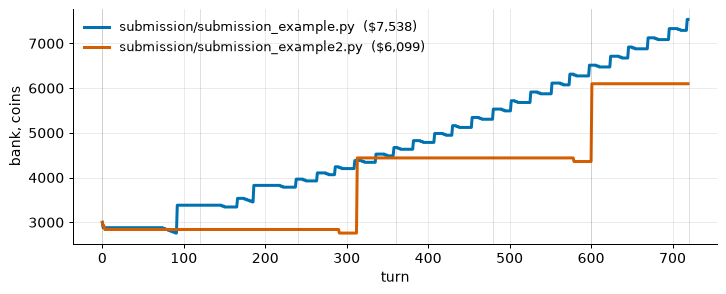

In [39]:
env = make("kaggriculture", configuration={"seed": 42}, debug=True)
agent_0 = "submission/submission_example.py"
agent_1 = "submission/submission_example2.py"
env.run([agent_0, agent_1])

money = {i: [step[0]["observation"]["farms"][i]["money"] for step in env.steps] for i in (0, 1)}
final = {i: env.steps[-1][i]["reward"] for i in (0, 1)}
print(f"{agent_0}: ${final[0]:,.0f}   {agent_1}: ${final[1]:,.0f}")

fig, ax = plt.subplots(figsize=(8.2, 3.4))
turns = np.arange(len(money[0]))
ax.plot(turns, money[0], color=P0, lw=2.4, label=f"{agent_0}  (${final[0]:,.0f})")
ax.plot(turns, money[1], color=P1, lw=2.4, label=f"{agent_1}  (${final[1]:,.0f})")
for d in range(0, 31, 5):
    ax.axvline(d * 24, color="#4A3F35", lw=.5, alpha=.25)
ax.set_xlabel("turn"); ax.set_ylabel("bank, coins")
ax.legend(fontsize=10, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()


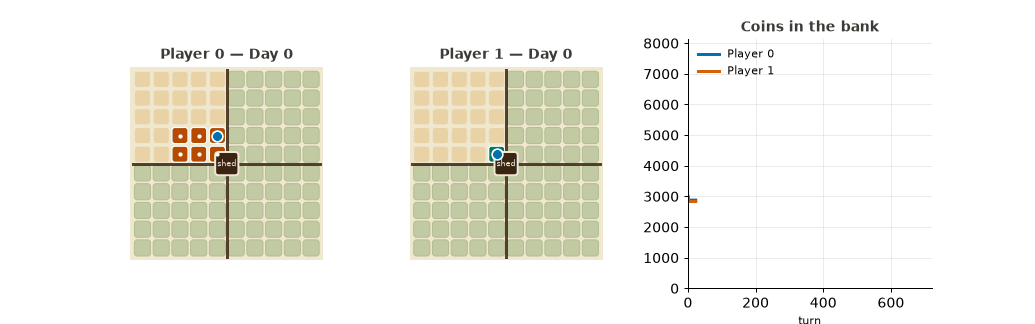

In [37]:
show_gif(season_gif_both(env.steps, out="gif/season_both.gif"))